# Assignment 4
Scipy statistics in Python walkthrough 
https://lectures.scientific-python.org/packages/statistics/index.html#data-representation-and-interaction

In [110]:
# import necessary packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy as sp

## Data representation and interaction
### Creating pandas dataframes

In [101]:
# pandas dataframes can be created from data in external files
data = pd.read_csv('brain_size.csv', sep=';', na_values=".", index_col=0)
data

,Gender,FSIQ,VIQ,PIQ,Weight,Height,MRI_Count
1,Female,133,132,124,118.0,64.5,816932
2,Male,140,150,124,NaN,72.5,1001121
3,Male,139,123,150,143.0,73.3,1038437
4,Male,133,129,128,172.0,68.8,965353
5,Female,137,132,134,147.0,65.0,951545
6,Female,99,90,110,146.0,69.0,928799
7,Female,138,136,131,138.0,64.5,991305
8,Female,92,90,98,175.0,66.0,854258
9,Male,89,93,84,134.0,66.3,904858
10,Male,133,114,147,172.0,68.8,955466


In [102]:
# pandas dataframes are similar to R dataframes
print(f'dataframe shape: {data.shape}')
print(f'dataframe columns: {data.columns}')

dataframe shape: (40, 7)
dataframe columns: Index(['Gender', 'FSIQ', 'VIQ', 'PIQ', 'Weight', 'Height', 'MRI_Count'], dtype='str')


In [103]:
# pandas dataframes are basically a dictionary with 1D series as the values 
# and as such, can be created from series, arrays and lists
# ex. {col_name: [1, 2, 3], col_name2: [4, 5, 6]}

t = np.linspace(-6, 6, 20)
sin_t = np.sin(t)
cos_t = np.cos(t)

pd.DataFrame({'t': t, 'sin': sin_t, 'cos': cos_t})

,t,sin,cos
0,-6.000000,0.279415,0.960170
1,-5.368421,0.792419,0.609977
2,-4.736842,0.999701,0.024451
3,-4.105263,0.821291,-0.570509
4,-3.473684,0.326021,-0.945363
5,-2.842105,-0.295030,-0.955488
6,-2.210526,-0.802257,-0.596979
7,-1.578947,-0.999967,-0.008151
8,-0.947368,-0.811882,0.583822
9,-0.315789,-0.310567,0.950551


### Manipulating dataframes

In [104]:
# Simpler selector
# used to select a subset of the dataframe and calculate 
# statistics on one of the columns in the subsetted dataframe
data[data['Gender'] == 'Female']['VIQ'].mean()


# Use the groupby function to split the dataframe up on categorical 
# variables and ccalculate the mean of the various groups
groupby_gender = data.groupby('Gender')
for gender, value in groupby_gender['VIQ']:
    print((gender, value.mean()))
    
groupby_gender.mean()

('Female', np.float64(109.45))
('Male', np.float64(115.25))


,FSIQ,VIQ,PIQ,Weight,Height,MRI_Count
Gender,,,,,,
Female,111.9,109.45,110.45,137.200000,65.765000,862654.6
Male,115.0,115.25,111.60,166.444444,71.431579,954855.4


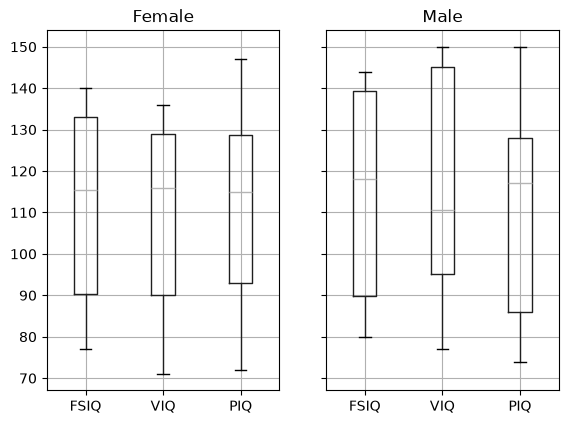

In [105]:
# Box plots of different columns for each gender
groupby_gender = data.groupby("Gender")
groupby_gender.boxplot(column=["FSIQ", "VIQ", "PIQ"]);

#### Exercise 58
Code in cell below

**What is the mean value for VIQ for the full population?**\
The mean value for VIQ for the full population is 112.35.

**How many males/females were included in this study?**\
There are 20 females and 20 males in the study. 

**What is the average value of MRI counts expressed in log units, for males and females?**\
The average value of MRI counts in log units is 13.77 for males and 13.67 for females.

In [106]:
## exercise 58
# calculate mean value for VIQ for full population
print(f'The mean value for VIQ for the full population is {data['VIQ'].mean()}')

# calculate number of males/females included in study
num_female = len(data[data['Gender'] == 'Female'])
num_male = len(data[data['Gender'] == 'Male'])
# data[data['Gender'] == 'Female']['VIQ'].count()

print(f'The number of females in the study is {num_female}')
print(f'The number of males in the study is {num_male}')

# calculate average value of MRI counts expressed in log units
for gender, value in groupby_gender['MRI_Count']:
    print(f'The log average value of MRI counts for {gender} is {np.log(value.mean())}')

The mean value for VIQ for the full population is 112.35
The number of females in the study is 20
The number of males in the study is 20
The log average value of MRI counts for Female is 13.66776965820175
The log average value of MRI counts for Male is 13.769315194386104


### Plotting data

Text(0.5, 0.95, 'PIQ, VIQ and FSIQ')

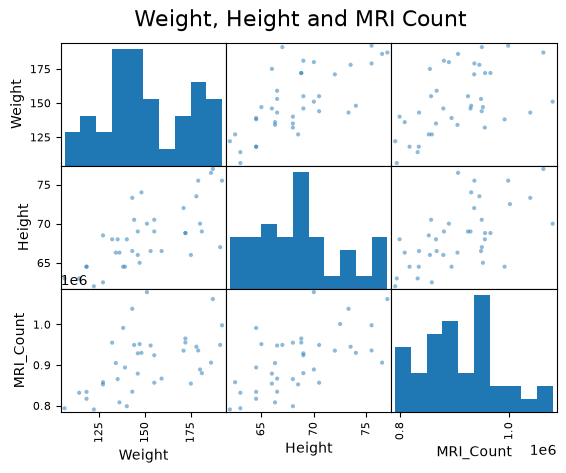

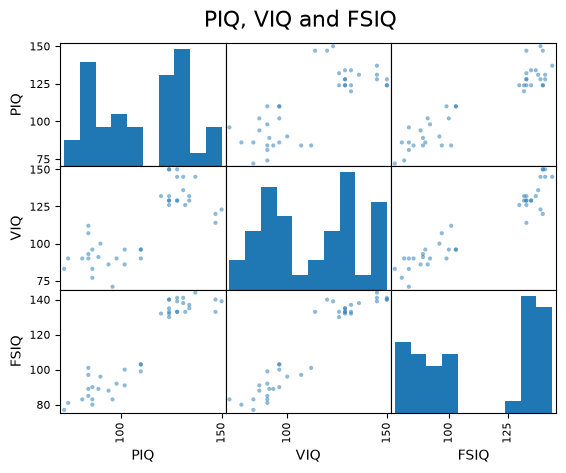

In [122]:
pd.plotting.scatter_matrix(data[['Weight', 'Height', 'MRI_Count']])
plt.suptitle("Weight, Height and MRI Count", fontsize=16, y=0.95)
pd.plotting.scatter_matrix(data[['PIQ', 'VIQ', 'FSIQ']])
plt.suptitle("PIQ, VIQ and FSIQ", fontsize=16, y=0.95)


#### Exercise 59

**Plot the scatter matrix for males only, and for females only. Do you think that the 2 sub-populations correspond to gender?**\
It doesn't appear that the 2 sub-populations correspond to gender, because the bi-modal distribution is still present in both the males only and females only scatter matrices.


female
[[<Axes: xlabel='Weight', ylabel='Weight'>
  <Axes: xlabel='Height', ylabel='Weight'>
  <Axes: xlabel='MRI_Count', ylabel='Weight'>]
 [<Axes: xlabel='Weight', ylabel='Height'>
  <Axes: xlabel='Height', ylabel='Height'>
  <Axes: xlabel='MRI_Count', ylabel='Height'>]
 [<Axes: xlabel='Weight', ylabel='MRI_Count'>
  <Axes: xlabel='Height', ylabel='MRI_Count'>
  <Axes: xlabel='MRI_Count', ylabel='MRI_Count'>]]
male


array([[<Axes: xlabel='Weight', ylabel='Weight'>,
        <Axes: xlabel='Height', ylabel='Weight'>,
        <Axes: xlabel='MRI_Count', ylabel='Weight'>],
       [<Axes: xlabel='Weight', ylabel='Height'>,
        <Axes: xlabel='Height', ylabel='Height'>,
        <Axes: xlabel='MRI_Count', ylabel='Height'>],
       [<Axes: xlabel='Weight', ylabel='MRI_Count'>,
        <Axes: xlabel='Height', ylabel='MRI_Count'>,
        <Axes: xlabel='MRI_Count', ylabel='MRI_Count'>]], dtype=object)

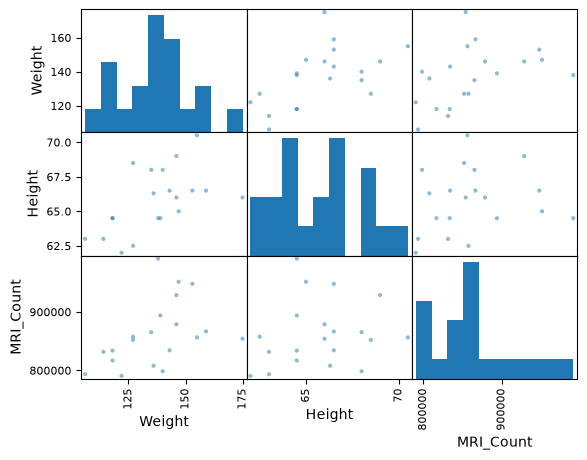

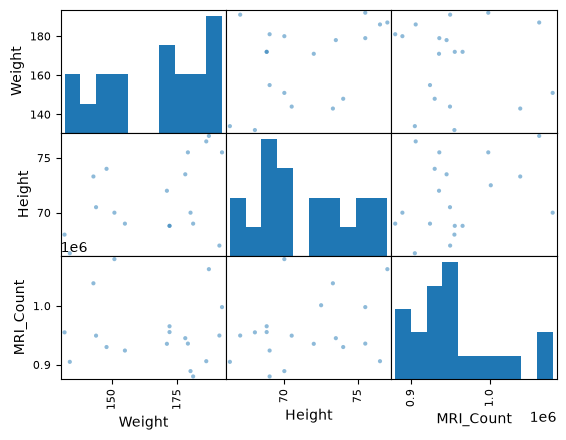

In [119]:
## exercise 59

# parameters = ['PIQ', 'VIQ', 'FSIQ']

parameters = ['Weight', 'Height', 'MRI_Count']

print("female")
print(pd.plotting.scatter_matrix(data[data['Gender'] == 'Female'][parameters]))

print("male")
pd.plotting.scatter_matrix(data[data['Gender'] == 'Male'][parameters])

## Hypothesis testing: comparing two groups
### Student's t-test
#### One sample tests: testing the value of a population mean

In [111]:
# test the null hypothesis that the mean of the population is equal to a given value
ttest = sp.stats.ttest_1samp(data['VIQ'], 0)
print(f'T-test result: {ttest}')


# test the null hypothesis that the mean of the population is equal to a given value 
# with the assumption that the data does not follow a normal distribution 
wilcoxon = sp.stats.wilcoxon(data['VIQ'])
print(f'Wilcoxon test result: {wilcoxon}')

T-test result: TtestResult(statistic=np.float64(30.08809997084933), pvalue=np.float64(1.3289196468727975e-28), df=np.int64(39))
Wilcoxon test result: WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(3.488172636231201e-08))


#### Two-sample t-test: testing for difference across populations

In [ ]:
# test whether the population means of two different populations are significantly different
female_viq = data[data['Gender'] == 'Female']['VIQ']
male_viq = data[data['Gender'] == 'Male']['VIQ']

print(f'Two-sample t-test result: {sp.stats.ttest_ind(female_viq, male_viq)}')

# test whether the population means of two different populations are significantly different 
# with the assumption that the data does not follow a normal distribution
print(f'Mann-Whitney non-parametric test result: {sp.stats.mannwhitneyu(female_viq, male_viq)}')


Two-sample t-test result: TtestResult(statistic=np.float64(-0.7726161723275012), pvalue=np.float64(0.44452876778583206), df=np.float64(38.0))
Mann-Whitney non-parametric test result: MannwhitneyuResult(statistic=np.float64(164.5), pvalue=np.float64(0.3422886868727315))


### Paired tests: repeated measurements on the same individuals

Text(0.5, 1.0, 'FSIQ and PIQ distributions')

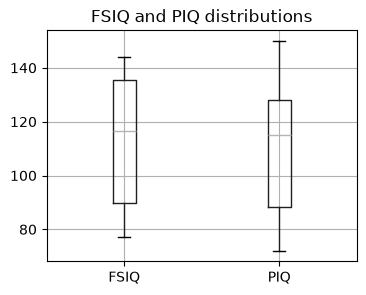

In [117]:
# Box plot of FSIQ and PIQ (different measures of IQ)
plt.figure(figsize=(4, 3))
data.boxplot(column=["FSIQ", "PIQ"])
plt.title('FSIQ and PIQ distributions')

In [113]:
# test whether FSIQ and PIQ are significantly different using unpaired test (not correct)
unpaired = sp.stats.ttest_ind(data['FSIQ'], data['PIQ'])
print(f'Unpaired test result: {unpaired}')

Unpaired test result: TtestResult(statistic=np.float64(0.465637596380964), pvalue=np.float64(0.6427725009414839), df=np.float64(78.0))


In [114]:
# test whether FSIQ and PIQ are significantly different using paired test 
# because the data is comprised of repeat measurements on the same individuals
paired = sp.stats.ttest_rel(data['FSIQ'], data['PIQ'])
print(f'Paired test result: {paired}')

Paired test result: TtestResult(statistic=np.float64(1.7842019405859857), pvalue=np.float64(0.08217263818364234), df=np.int64(39))


([<matplotlib.axis.XTick at 0x301485a90>], [Text(1, 0, 'FSIQ - PIQ')])

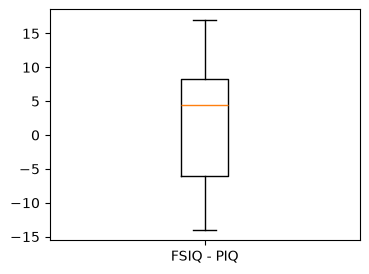

In [116]:
# Boxplot of the difference between the FSIQ and PIQ measurements
plt.figure(figsize=(4, 3))
plt.boxplot(data["FSIQ"] - data["PIQ"])
plt.xticks((1,), ("FSIQ - PIQ",))


In [49]:
# Paired test on 2 sets of data (ex init and final) is 
# equivalent to a one-sample test on the differences between paired observations
sp.stats.ttest_1samp(data['FSIQ'] - data['PIQ'], 0)

TtestResult(statistic=np.float64(1.7842019405859857), pvalue=np.float64(0.08217263818364234), df=np.int64(39))

In [50]:
# non-parametric version
sp.stats.wilcoxon(data['FSIQ'], data['PIQ'], method="approx")

WilcoxonResult(statistic=np.float64(274.5), pvalue=np.float64(0.10659492713506856))

#### Exercise 60
**Test the difference between weights in males and females.**
The weights are not significantly different between males and females. 
**Use non parametric statistics to test the difference between VIQ in males and females.**
The non-parametric test does not indicate a significant difference between VIQ in males and females. 

In [59]:
female_weight = data[data['Gender'] == 'Female']['Weight'].dropna()
male_weight = data[data['Gender'] == 'Male']['Weight'].dropna()

print(f'Two-sample t-test on weights in males vs. females: {sp.stats.ttest_ind(female_weight, male_weight)}')
print(f'Mann-Whitney non-parametric test result: {sp.stats.mannwhitneyu(female_viq, male_viq)}')


Two-sample t-test on weights in males vs. females: TtestResult(statistic=np.float64(-4.870950921940696), pvalue=np.float64(2.2272930183621256e-05), df=np.float64(36.0))
Mann-Whitney non-parametric test result: MannwhitneyuResult(statistic=np.float64(164.5), pvalue=np.float64(0.3422886868727315))


## Linear models, multiple factors, and analysis of variance
### “formulas” to specify statistical models in Python
#### A simple linear regression
Test the hypothesis that y is a linear function of x:
$$y=x*coef+intercept+e $$
where e is observation noise

1. Fit a linear model using ordinary least squares
2. Test that the coefficient is not zero


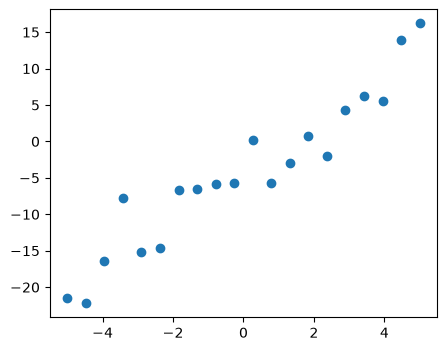

In [60]:
x = np.linspace(-5, 5, 20)

# To get reproducible values, provide a seed value
rng = np.random.default_rng(27446968)

# normal distributed noise
y = -5 + 3 * x + 4 * rng.normal(size=x.shape)

# Create a data frame containing all the relevant variables
data = pd.DataFrame({'x': x, 'y': y})

# Plot the data
plt.figure(figsize=(5, 4))
plt.plot(x, y, "o");

In [62]:
# specify and fit an OLS model
import statsmodels.formula.api as smf
model = smf.ols("y ~ x", data).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.901
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     164.5
Date:                Wed, 01 Jul 2026   Prob (F-statistic):           1.72e-10
Time:                        10:44:55   Log-Likelihood:                -51.758
No. Observations:                  20   AIC:                             107.5
Df Residuals:                      18   BIC:                             109.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -4.2948      0.759     -5.661      0.000      -5.889      -2.701
x              3.2060      0.250     12.825      0.000       2.681       3.731
==============================================================================
Omnibus:                        1.218   Durbin-Watson:                   1.796
Prob(Omnibus):                  0.544   Jarque-Bera (JB):                0.999
Skew:                           0.503   Prob(JB):                        0.607
Kurtosis:                       2.568   Cond. No.                         3.03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

##### Exercise 61
**Retrieve the estimated parameters from the model above**
- Intercept = -4.29
- x = 3.21

In [69]:
model.params

Intercept   -4.294824
x            3.205979
dtype: float64

#### Categorical variables: comparing groups or multiple categories

In [71]:
data = pd.read_csv('brain_size.csv', sep=';', na_values=".")
model = smf.ols("VIQ ~ Gender + 1", data).fit()
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    VIQ   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                 -0.010
Method:                 Least Squares   F-statistic:                    0.5969
Date:                Wed, 01 Jul 2026   Prob (F-statistic):              0.445
Time:                        10:51:54   Log-Likelihood:                -182.42
No. Observations:                  40   AIC:                             368.8
Df Residuals:                      38   BIC:                             372.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        109.4500      5.308     20.619      0.000      98.704     120.196
Gender[T.Male]     5.8000      7.507      0.773      0.445      -9.397      20.997
==============================================================================
Omnibus:                       26.188   Durbin-Watson:                   1.709
Prob(Omnibus):                  0.000   Jarque-Bera (JB):                3.703
Skew:                           0.010   Prob(JB):                        0.157
Kurtosis:                       1.510   Cond. No.                         2.62
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### Link to t-tests between different FSIQ and PIQ

In [72]:
# create long form table to compare different types of IQ
data_fisq = pd.DataFrame({'iq': data['FSIQ'], 'type': 'fsiq'})
data_piq = pd.DataFrame({'iq': data['PIQ'], 'type': 'piq'})
data_long = pd.concat((data_fisq, data_piq))
data_long

,iq,type
0,133,fsiq
1,140,fsiq
2,139,fsiq
3,133,fsiq
4,137,fsiq
...,...,...
35,128,piq
36,124,piq
37,94,piq
38,74,piq


In [73]:
model = smf.ols("iq ~ type", data_long).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     iq   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.010
Method:                 Least Squares   F-statistic:                    0.2168
Date:                Wed, 01 Jul 2026   Prob (F-statistic):              0.643
Time:                        10:53:36   Log-Likelihood:                -364.35
No. Observations:                  80   AIC:                             732.7
Df Residuals:                      78   BIC:                             737.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept     113.4500      3.683     30.807      0.000     106.119     120.781
type[T.piq]    -2.4250      5.208     -0.466      0.643     -12.793       7.943
==============================================================================
Omnibus:                      164.598   Durbin-Watson:                   1.531
Prob(Omnibus):                  0.000   Jarque-Bera (JB):                8.062
Skew:                          -0.110   Prob(JB):                       0.0178
Kurtosis:                       1.461   Cond. No.                         2.62
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Multiple Regression: including multiple factors

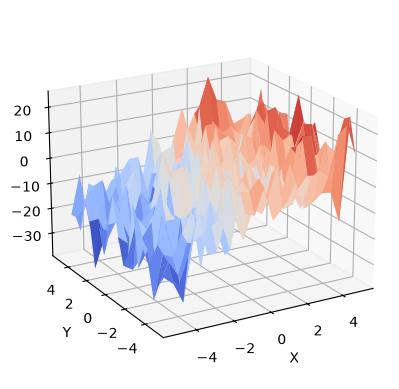

In [74]:
# Generate and show the data
x = np.linspace(-5, 5, 21)

# Generate a 2D grid
X, Y = np.meshgrid(x, x)

# To get reproducible values, provide a seed value
rng = np.random.default_rng(27446968)

# Z is the elevation of this 2D grid
Z = -5 + 3 * X - 0.5 * Y + 8 * rng.normal(size=X.shape)

# Plot the data
ax = plt.figure().add_subplot(projection="3d")
surf = ax.plot_surface(X, Y, Z, cmap="coolwarm", rstride=1, cstride=1)
ax.view_init(20, -120)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z");

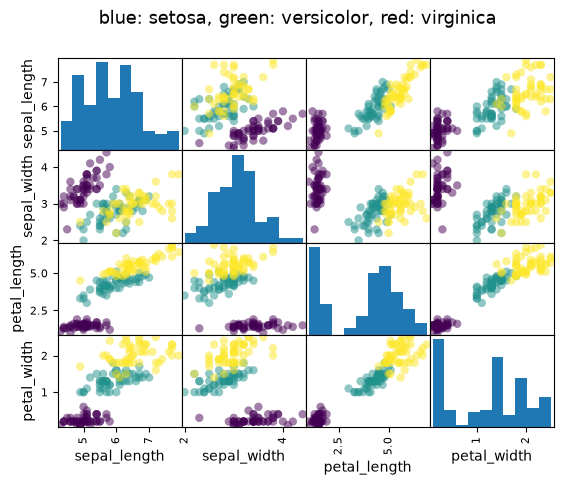

In [75]:
data = pd.read_csv('iris.csv')
# Express the names as categories
categories = pd.Categorical(data["name"])
# The parameter 'c' is passed to plt.scatter and will control the color
pd.plotting.scatter_matrix(data, c=categories.codes, marker="o")
fig = plt.gcf()
fig.suptitle("blue: setosa, green: versicolor, red: virginica", size=13);

In [77]:
# explain sepal length as a fx of petal width and category
model = smf.ols("sepal_width ~ name + petal_length", data).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            sepal_width   R-squared:                       0.478
Model:                            OLS   Adj. R-squared:                  0.468
Method:                 Least Squares   F-statistic:                     44.63
Date:                Wed, 01 Jul 2026   Prob (F-statistic):           1.58e-20
Time:                        10:57:15   Log-Likelihood:                -38.185
No. Observations:                 150   AIC:                             84.37
Df Residuals:                     146   BIC:                             96.41
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              2.9813      0.099     29.989      0.000       2.785       3.178
name[T.versicolor]    -1.4821      0.181     -8.190      0.000      -1.840      -1.124
name[T.virginica]     -1.6635      0.256     -6.502      0.000      -2.169      -1.158
petal_length           0.2983      0.061      4.920      0.000       0.178       0.418
==============================================================================
Omnibus:                        2.868   Durbin-Watson:                   1.753
Prob(Omnibus):                  0.238   Jarque-Bera (JB):                2.885
Skew:                          -0.082   Prob(JB):                        0.236
Kurtosis:                       3.659   Cond. No.                         54.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Post-hoc hypothesis testing: analysis of variance (ANOVA)
Want to test if the petal length is different between versicolor and virginica, after removing the effect of sepal width. This can be formulated as testing the difference between the coefficient associated to versicolor and virginica in the linear model estimated above

In [78]:
print(model.f_test([0, 1, -1, 0]))

<F test: F=3.2453353465741883, p=0.07369058781701086, df_denom=146, df_num=1>


#### Exercise 62
**Going back to the brain size + IQ data, test if the VIQ of male and female are different after removing the effect of brain size, height and weight.**
The VIQ of males and females is not different after removing brain size, height and weight.

In [87]:
data = pd.read_csv('brain_size.csv', sep=';', na_values=".")

model = smf.ols('VIQ ~ Gender + MRI_Count + Height', data).fit()
print(model.summary())

print(model.f_test([0, 1, 0, 0]))

                            OLS Regression Results                            
Dep. Variable:                    VIQ   R-squared:                       0.246
Model:                            OLS   Adj. R-squared:                  0.181
Method:                 Least Squares   F-statistic:                     3.809
Date:                Wed, 01 Jul 2026   Prob (F-statistic):             0.0184
Time:                        14:48:35   Log-Likelihood:                -172.34
No. Observations:                  39   AIC:                             352.7
Df Residuals:                      35   BIC:                             359.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        166.6258     88.824      1.

## More visualization: Seaborn for statistical exploration

In [88]:
import seaborn

In [89]:
data = pd.read_csv("wages.csv",
    skiprows=27,
    skipfooter=6,
    sep=None,
    header=None,
    engine="python"  # To allow use of skipfooter.
)
# Give names to the columns
names = [
    "education: Number of years of education",
    "south: 1=person lives in South, 0=Person lives elsewhere",
    "sex: 1=female, 0=Male",
    "experience: Number of years of work experience",
    "union: 1=union member, 0=Not union member",
    "wage: wage (dollars per hour)",
    "age: years",
    "race: 1=other, 2=Hispanic, 3=White",
    "occupation: 1=Management, 2=Sales, 3=Clerical, 4=Service, 5=Professional, 6=Other",
    "sector: 0=Other, 1=Manufacturing, 2=Construction",
    "marr: 0=unmarried,  1=Married",
]
short_names = [n.split(":")[0] for n in names]
data.columns = pd.Index(short_names)
# Log-transform the wages, because they typically are increased with
# multiplicative factors
data["wage"] = np.log10(data["wage"])
# Convert genders to strings (this is particularly useful so that the
# statsmodels formulas detects that `sex` is a categorical variable)
data["sex"] = np.choose(data['sex'], ["male", "female"])

In [90]:
data

,education,south,sex,experience,union,wage,age,race,occupation,sector,marr
0,8,0,female,21,0,0.707570,35,2,6,1,1
1,9,0,female,42,0,0.694605,57,3,6,1,1
2,12,0,male,1,0,0.824126,19,3,6,1,0
3,12,0,male,4,0,0.602060,22,3,6,0,0
4,12,0,male,17,0,0.875061,35,3,6,0,1
...,...,...,...,...,...,...,...,...,...,...,...
529,18,0,male,5,0,1.055378,29,3,5,0,0
530,12,0,female,33,0,0.785330,51,1,5,0,1
531,17,0,female,25,1,1.366423,48,1,5,0,1
532,12,1,male,13,1,1.298416,31,3,5,0,1


### Pairplot: scatter matrices

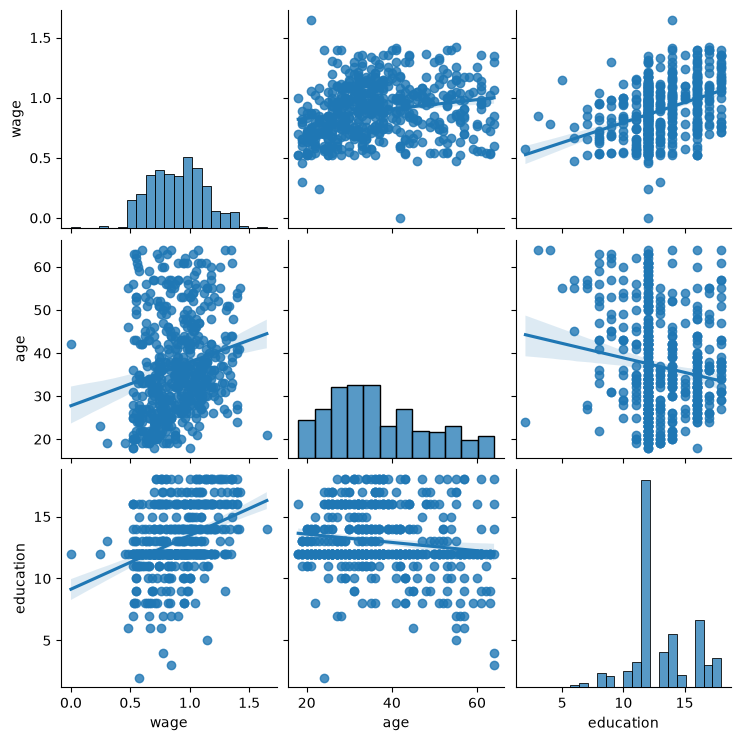

In [91]:
seaborn.pairplot(data, vars=['wage', 'age', 'education'], kind='reg');

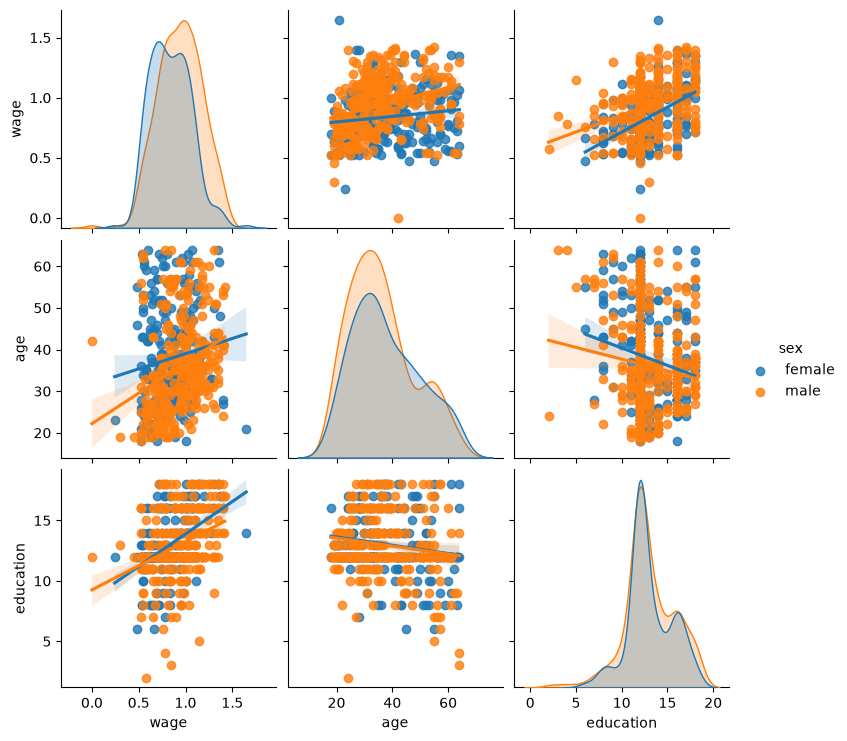

In [93]:
seaborn.pairplot(data, vars=['wage', 'age', 'education'],
                 kind='reg', hue='sex')

### lmplot: plotting a univariate regression

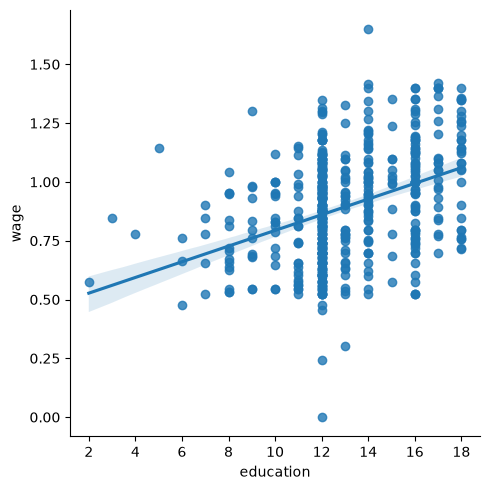

In [94]:
seaborn.lmplot(y='wage', x='education', data=data)

## Testing for interactions

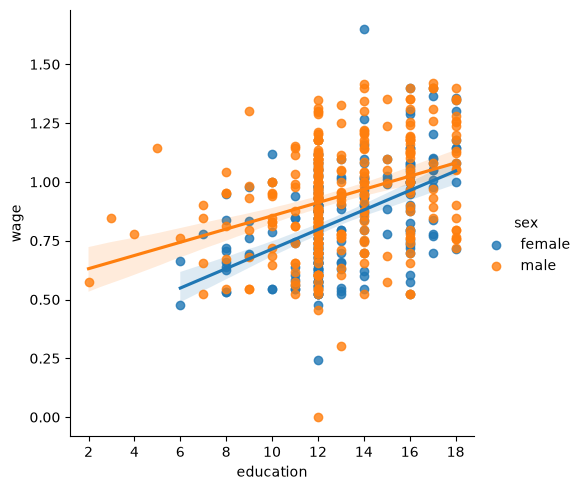

In [97]:
seaborn.lmplot(y="wage", x="education", hue="sex", data=data)

In [98]:
result = smf.ols(formula="wage ~ education + sex", data=data).fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   wage   R-squared:                       0.193
Model:                            OLS   Adj. R-squared:                  0.190
Method:                 Least Squares   F-statistic:                     63.42
Date:                Wed, 01 Jul 2026   Prob (F-statistic):           2.01e-25
Time:                        14:58:42   Log-Likelihood:                 86.654
No. Observations:                 534   AIC:                            -167.3
Df Residuals:                     531   BIC:                            -154.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       0.4053      0.046      8.732      0.000       0.314       0.496
sex[T.male]     0.1008      0.018      5.625      0.000       0.066       0.136
education       0.0334      0.003      9.768      0.000       0.027       0.040
==============================================================================
Omnibus:                        4.675   Durbin-Watson:                   1.792
Prob(Omnibus):                  0.097   Jarque-Bera (JB):                4.876
Skew:                          -0.147   Prob(JB):                       0.0873
Kurtosis:                       3.365   Cond. No.                         69.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""